# Part II – Vision Task: Facial Emotion Recognition


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imports & Setup
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D, Input
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/AI&ML/Dataset- facial expressions.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/")

train_dir = "/content/train"
test_dir  = "/content/test"
print("Dataset extracted!")
print("Train classes:", os.listdir(train_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted!
Train classes: ['surprise', 'angry', 'disgust', 'neutral', 'sad', 'fear', 'happy']


# Data Understanding & EDA

Full Class Distribution (7 classes):


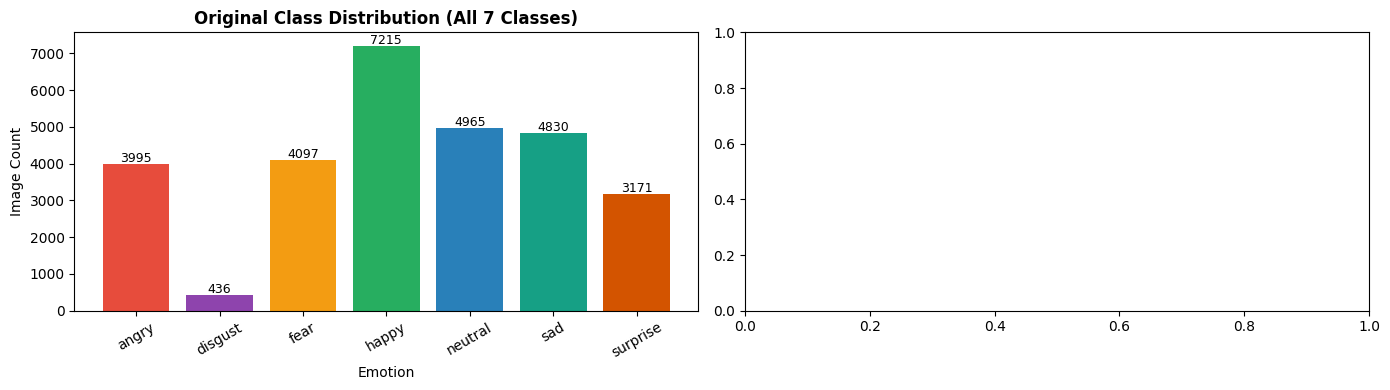

In [4]:
# All 7 classes first
all_classes = sorted(os.listdir(train_dir))
all_counts  = {c: len(os.listdir(os.path.join(train_dir, c))) for c in all_classes}

print("Full Class Distribution (7 classes):")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(all_counts.keys(), all_counts.values(),
            color=['#e74c3c','#8e44ad','#f39c12','#27ae60','#2980b9','#16a085','#d35400'])
axes[0].set_title('Original Class Distribution (All 7 Classes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Image Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (c, n) in enumerate(all_counts.items()):
    axes[0].text(i, n + 50, str(n), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Final Classes & Image Size Check

# Droping  disgust because of severe imbalance
classes = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(classes)
print(f"Working with {NUM_CLASSES} classes: {classes}")

# Check image sizes
sizes = set()
for cls in classes:
    path = os.path.join(train_dir, cls)
    for fname in os.listdir(path)[:10]:
        img = cv2.imread(os.path.join(path, fname))
        if img is not None:
            sizes.add(img.shape)
print(f"Image size: {sizes}")

# Per-class counts for the 6 we use
train_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(test_dir,  c))) for c in classes}

print("\n6-Class Distribution:")
print(f"{'Class':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for c in classes:
    print(f"{c:<12} {train_counts[c]:>8} {test_counts[c]:>8}")
print(f"{'TOTAL':<12} {sum(train_counts.values()):>8} {sum(test_counts.values()):>8}")

Working with 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Image size: {(48, 48, 3)}

6-Class Distribution:
Class           Train     Test
------------------------------
angry            3995      958
fear             4097     1024
happy            7215     1774
neutral          4965     1233
sad              4830     1247
surprise         3171      831
TOTAL           28273     7067


#Sample Images Per Class

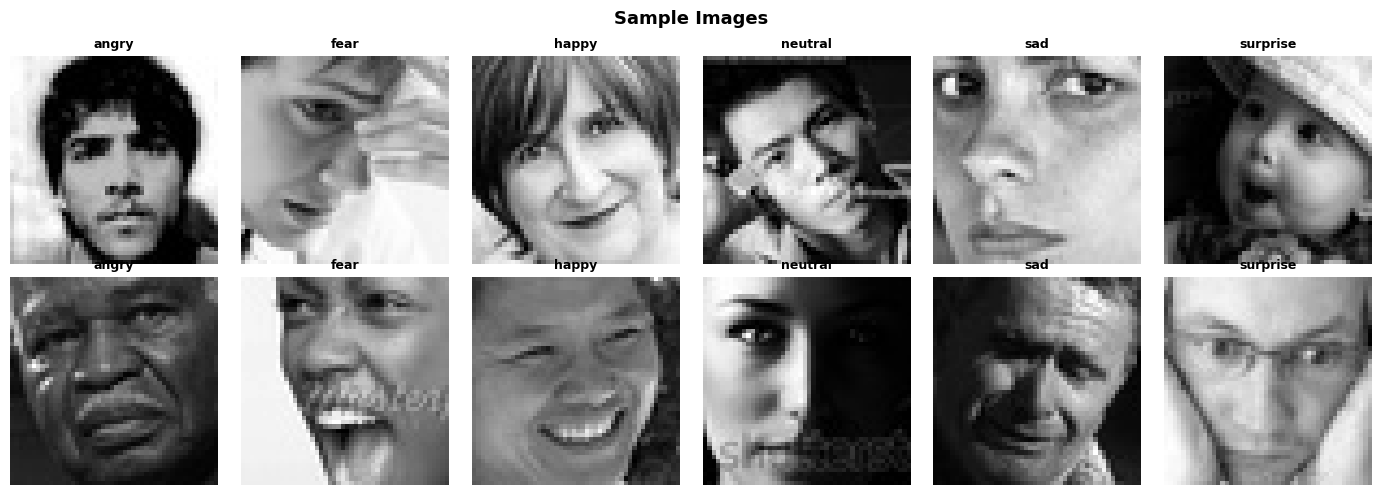

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    imgs = random.sample(os.listdir(cls_path), 2)
    for row in range(2):
        img = cv2.imread(os.path.join(cls_path, imgs[row]), cv2.IMREAD_GRAYSCALE)
        axes[row, i].imshow(img, cmap='gray')
        axes[row, i].set_title(cls, fontsize=9, fontweight='bold')
        axes[row, i].axis('off')

plt.suptitle('Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#Data Generators and Augmentation

In [7]:
IMG_SIZE   = (48, 48)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2,
    rotation_range   = 10,
    zoom_range       = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip  = True,

)

val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', subset='training', seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', subset='validation', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', shuffle=False
)

print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples      : {test_gen.samples}")
print(f"Class mapping     : {train_gen.class_indices}")

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Training samples  : 22619
Validation samples: 5654
Test samples      : 7067
Class mapping     : {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}


# Class Weights to balanced Data

In [13]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class Weights (higher = more attention during training):")
for i, cls in enumerate(classes):
    print(f"  {cls:<12}: {class_weight_dict[i]:.3f}")


Class Weights (higher = more attention during training):
  angry       : 1.180
  fear        : 1.150
  happy       : 0.653
  neutral     : 0.949
  sad         : 0.976
  surprise    : 1.486


# Functions - for repeated Histroy, evaluation, sample inference

In [14]:
def plot_history(history, title, color='steelblue'):
    """Plot training curves — accuracy and loss side by side."""
    epochs = range(1, len(history.history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history.history['accuracy'],     color=color,      lw=2, label='Train')
    axes[0].plot(epochs, history.history['val_accuracy'], color=color, lw=2, ls='--', label='Validation')
    axes[0].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history.history['loss'],     color='tomato', lw=2, label='Train')
    axes[1].plot(epochs, history.history['val_loss'], color='tomato', lw=2, ls='--', label='Validation')
    axes[1].set_title(f'{title} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, generator, model_name):
    """Evaluate model, print report, return predictions and accuracy."""
    generator.reset()
    preds = model.predict(generator, verbose=1)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = generator.classes
    acc = np.mean(pred_classes == true_classes) * 100

    print(f"\n{'='*55}")
    print(f"{model_name} — Test Accuracy: {acc:.2f}%")
    print(f"{'='*55}")
    print(classification_report(true_classes, pred_classes,
                                target_names=classes, digits=3))

    cm = confusion_matrix(true_classes, pred_classes)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(classes, rotation=35)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(classes)
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color=color, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return pred_classes, true_classes, acc


def sample_inference(model, test_dir, classes, model_name, color_mode='grayscale', size=(48, 48)):
    """Show sample predictions on 6 images (1 per class)."""
    sample_imgs, sample_labels = [], []
    for cls in classes:
        cls_path = os.path.join(test_dir, cls)
        fnames = os.listdir(cls_path)
        img_path = os.path.join(cls_path, random.choice(fnames))
        if color_mode == 'grayscale':
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        sample_imgs.append(img)
        sample_labels.append(cls)

    if color_mode == 'grayscale':
        arr = np.array(sample_imgs).reshape(-1, size[0], size[1], 1) / 255.0
    else:
        arr = np.array(sample_imgs) / 255.0

    preds      = model.predict(arr, verbose=0)
    pred_labels = [classes[np.argmax(p)] for p in preds]
    confidence  = [np.max(p) * 100 for p in preds]

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        if color_mode == 'grayscale':
            axes[i].imshow(sample_imgs[i], cmap='gray')
        else:
            axes[i].imshow(sample_imgs[i])
        color = 'green' if pred_labels[i] == sample_labels[i] else 'red'
        axes[i].set_title(
            f"True: {sample_labels[i]}\nPred: {pred_labels[i]}\n{confidence[i]:.0f}%",
            color=color, fontsize=8
        )
        axes[i].axis('off')
    plt.suptitle(f'{model_name} — Sample Inference (Green=Correct, Red=Wrong)', fontweight='bold')
    plt.tight_layout()
    plt.show()


def get_callbacks(monitor='val_accuracy', patience_lr=4, patience_es=10, save_path=None):
    """Standard callback set: ReduceLR + EarlyStopping + optional ModelCheckpoint."""
    cbs = [
        ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=patience_lr,
                          min_lr=1e-6, verbose=1, mode='max'),
        EarlyStopping(monitor=monitor, patience=patience_es,
                      restore_best_weights=True, verbose=1, mode='max'),
    ]
    if save_path:
        cbs.append(ModelCheckpoint(save_path, monitor=monitor, save_best_only=True,
                                    verbose=0, mode='max'))
    return cbs

print("Helper functions defined.")

Helper functions defined.


# **PART A — BASELINE CNN MODEL**

In [15]:
def build_baseline_model():
    model = Sequential([
        # ── Block 1: 32 filters, 3×3 kernel
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Block 2: 64 filters, 3×3 kernel
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Block 3: 128 filters, 3×3 kernel
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Flatten + 3 FCN layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),

        # ── Output
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,316,550 (5.02 MB)

 Trainable params: 1,315,334 (5.02 MB)

 Non-trainable params: 1,216 (4.75 KB)

##**Train Baseline**

In [16]:
print("Training Baseline CNN...")
t0 = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=10),
    verbose         = 1
)

baseline_time = (time.time() - t0) / 60
print(f"\nBaseline Training Time: {baseline_time:.1f} min")
print(f"Epochs completed: {len(baseline_history.history['accuracy'])}")

Training Baseline CNN...
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.2219 - loss: 1.8594 - val_accuracy: 0.1970 - val_loss: 1.8702 - learning_rate: 0.0010
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.2961 - loss: 1.6755 - val_accuracy: 0.3527 - val_loss: 1.5728 - learning_rate: 0.0010
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.3677 - loss: 1.5612 - val_accuracy: 0.4259 - val_loss: 1.4313 - learning_rate: 0.0010
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.4218 - loss: 1.4679 - val_accuracy: 0.3919 - val_loss: 1.5334 - learning_rate: 0.0010
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.4499 - loss: 1.4043 - val_accuracy: 0.4264 - val_loss: 1.4255 - learning_rate: 0.0010
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.4754 - loss: 1.3501 - val_accuracy: 0.4989 - val_loss: 1.2816 - learning_rate: 0.0010
Epoch 7/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/st

##Baseline — Plots + Evaluation

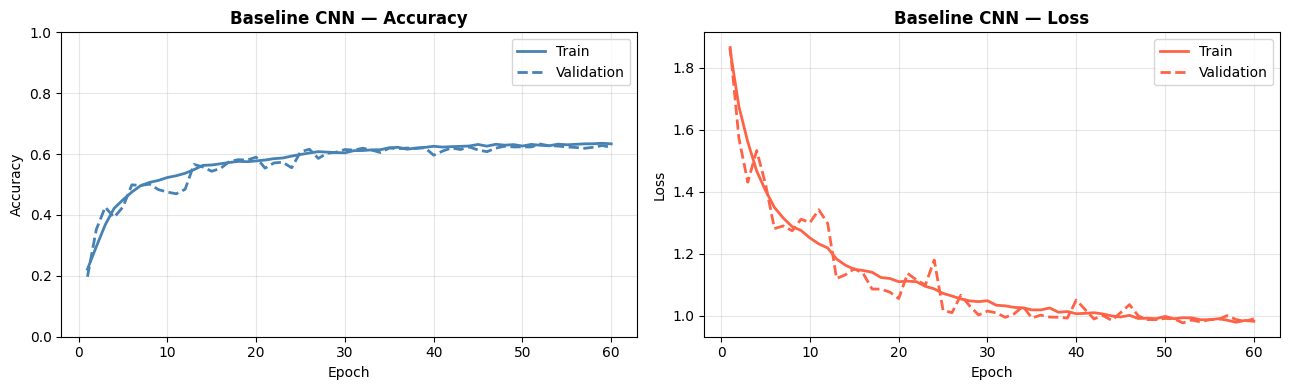

In [17]:
plot_history(baseline_history, 'Baseline CNN', color='steelblue')

111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

Baseline CNN — Test Accuracy: 63.73%
              precision    recall  f1-score   support

       angry      0.553     0.600     0.576       958
        fear      0.562     0.325     0.412      1024
       happy      0.872     0.815     0.842      1774
     neutral      0.516     0.749     0.612      1233
         sad      0.537     0.428     0.476      1247
    surprise      0.698     0.833     0.760       831

    accuracy                          0.637      7067
   macro avg      0.623     0.625     0.613      7067
weighted avg      0.642     0.637     0.629      7067



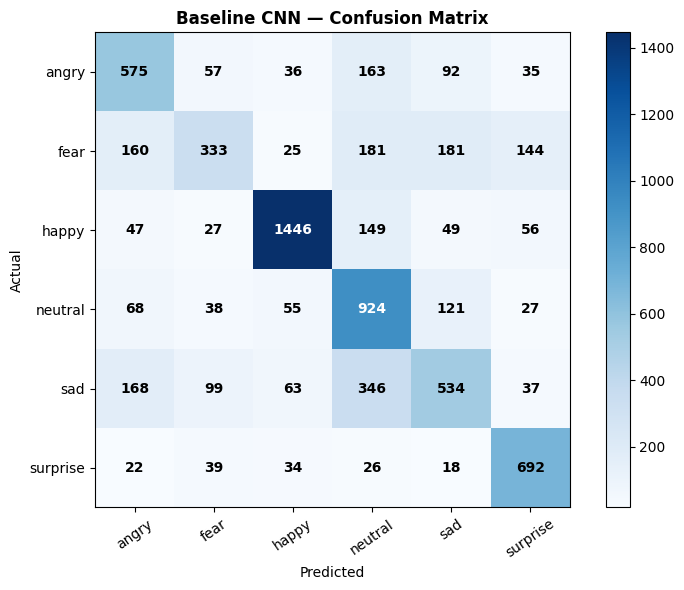

In [18]:
b_preds, b_true, baseline_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

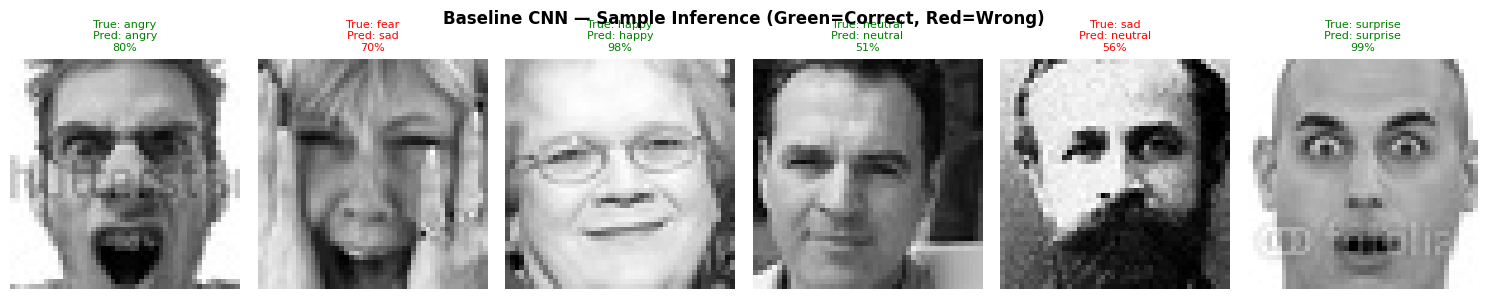

In [19]:
sample_inference(baseline_model, test_dir, classes, 'Baseline CNN', 'grayscale', (48, 48))

#PART A — DEEPER CNN MODEL

In [20]:
def build_deeper_model():
    model = Sequential([
        # ── Block 1: 32 filters
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        # ── Block 2: 64 filters
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        # ── Block 3+4: 128 filters (two convs, one pool)
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── Block 5+6: 256 filters (two convs, one pool)
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── FCN — 3 layers, aggressive regularisation
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),

        # ── Output
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_model()
deeper_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
deeper_model.summary()
print(f"\nBaseline params : {baseline_model.count_params():,}")
print(f"Deeper   params : {deeper_model.count_params():,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       590,08

 Total params: 1,762,118 (6.72 MB)

 Trainable params: 1,759,622 (6.71 MB)

 Non-trainable params: 2,496 (9.75 KB)


Baseline params : 1,316,550
Deeper   params : 1,762,118


## Train Deeper (Adam)

In [21]:
print("Training Deeper CNN with Adam...")
t0 = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=10),
    verbose         = 1
)

deeper_time = (time.time() - t0) / 60
print(f"\nDeeper (Adam) Training Time: {deeper_time:.1f} min")
print(f"Epochs completed: {len(deeper_history.history['accuracy'])}")

Training Deeper CNN with Adam...
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 49s 96ms/step - accuracy: 0.1970 - loss: 2.0466 - val_accuracy: 0.2239 - val_loss: 1.9355 - learning_rate: 5.0000e-04
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.2071 - loss: 1.8886 - val_accuracy: 0.2473 - val_loss: 1.8576 - learning_rate: 5.0000e-04
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.2379 - loss: 1.8232 - val_accuracy: 0.2149 - val_loss: 2.0402 - learning_rate: 5.0000e-04
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.2725 - loss: 1.7566 - val_accuracy: 0.3364 - val_loss: 1.7029 - learning_rate: 5.0000e-04
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.3175 - loss: 1.6937 - val_accuracy: 0.2598 - val_loss: 1.8575 - learning_rate: 5.0000e-04
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.3651 - loss: 1.6344 - val_accuracy: 0.4367 - val_loss: 1.4890 - learning_rate: 5.0000e-04
Epoch 7/60
354/354 

##Deeper — Plots + Evaluation


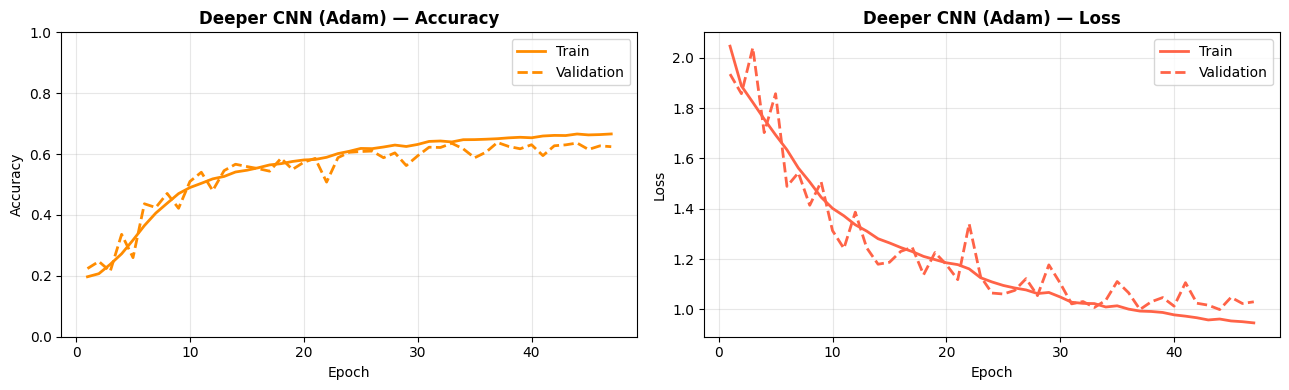

In [22]:
plot_history(deeper_history, 'Deeper CNN (Adam)', color='darkorange')


111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step

Deeper CNN (Adam) — Test Accuracy: 65.23%
              precision    recall  f1-score   support

       angry      0.606     0.577     0.591       958
        fear      0.590     0.336     0.428      1024
       happy      0.851     0.854     0.852      1774
     neutral      0.516     0.756     0.613      1233
         sad      0.562     0.456     0.504      1247
    surprise      0.717     0.839     0.773       831

    accuracy                          0.652      7067
   macro avg      0.640     0.636     0.627      7067
weighted avg      0.655     0.652     0.643      7067



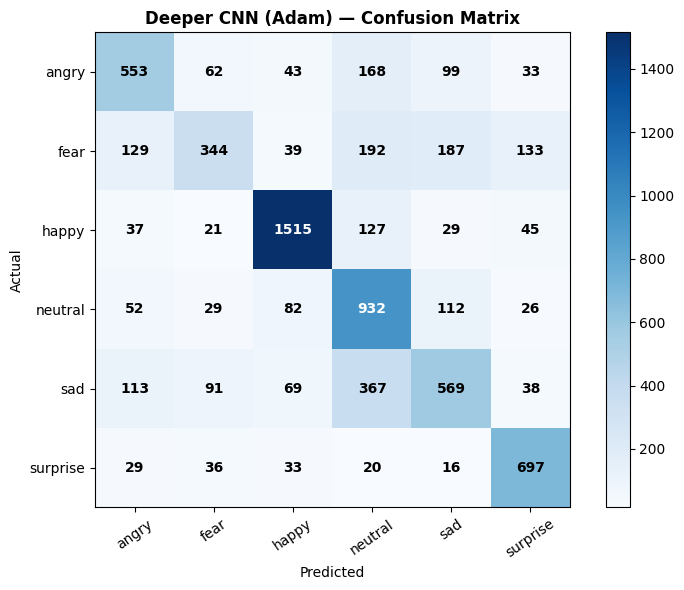

In [23]:
d_preds, d_true, deeper_acc = evaluate_model(deeper_model, test_gen, 'Deeper CNN (Adam)')

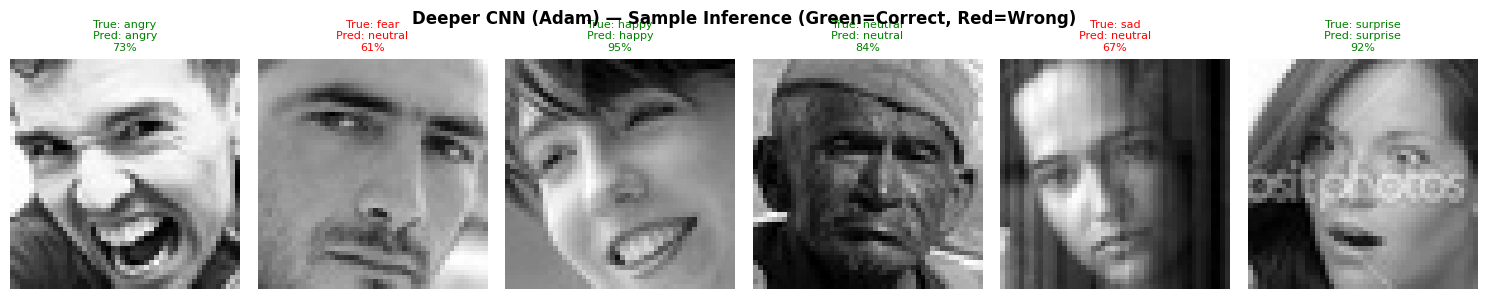

In [24]:
sample_inference(deeper_model, test_dir, classes, 'Deeper CNN (Adam)', 'grayscale', (48, 48))

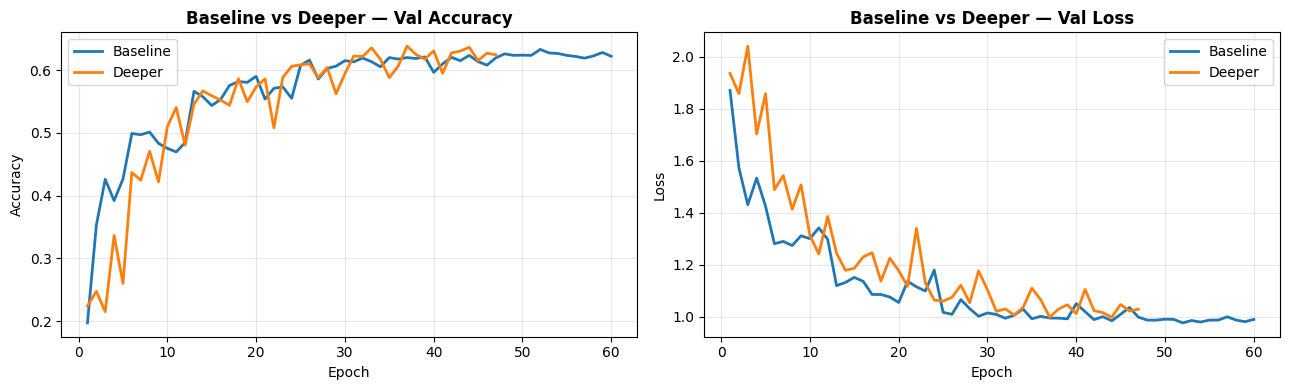

In [25]:
# Baseline vs Deeper overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_b = range(1, len(baseline_history.history['val_accuracy']) + 1)
e_d = range(1, len(deeper_history.history['val_accuracy']) + 1)

axes[0].plot(e_b, baseline_history.history['val_accuracy'], label='Baseline', lw=2)
axes[0].plot(e_d, deeper_history.history['val_accuracy'],  label='Deeper',   lw=2)
axes[0].set_title('Baseline vs Deeper — Val Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e_b, baseline_history.history['val_loss'], label='Baseline', lw=2)
axes[1].plot(e_d, deeper_history.history['val_loss'],  label='Deeper',   lw=2)
axes[1].set_title('Baseline vs Deeper — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

##SGD Model (Same Architecture as Deeper)

In [26]:
sgd_model = build_deeper_model()
sgd_model._name = 'Deeper_CNN_SGD'
sgd_model.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("SGD model (Nesterov momentum) compiled")

t0 = time.time()
sgd_history = sgd_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=5, patience_es=12),
    verbose         = 1
)
sgd_time = (time.time() - t0) / 60
print(f"\nSGD Training Time: {sgd_time:.1f} min")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD model (Nesterov momentum) compiled
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.1996 - loss: 1.9131 - val_accuracy: 0.2351 - val_loss: 1.8206 - learning_rate: 0.0100
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.2195 - loss: 1.8383 - val_accuracy: 0.2504 - val_loss: 1.8057 - learning_rate: 0.0100
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.2413 - loss: 1.8105 - val_accuracy: 0.1880 - val_loss: 1.8620 - learning_rate: 0.0100
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.2621 - loss: 1.7748 - val_accuracy: 0.1781 - val_loss: 2.1174 - learning_rate: 0.0100
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.2791 - loss: 1.7414 - val_accuracy: 0.3185 - val_loss: 1.6924 - learning_rate: 0.0100
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.3017 - loss: 1.7105 - val_accuracy: 0.1969 - val_loss: 2.1504 - learning_rate: 0.0100
Epoch 7/60
354/354 ━━━━━━━━━━━━━━━━━━

In [27]:
## SGD Evaluation + Adam vs SGD Comparison

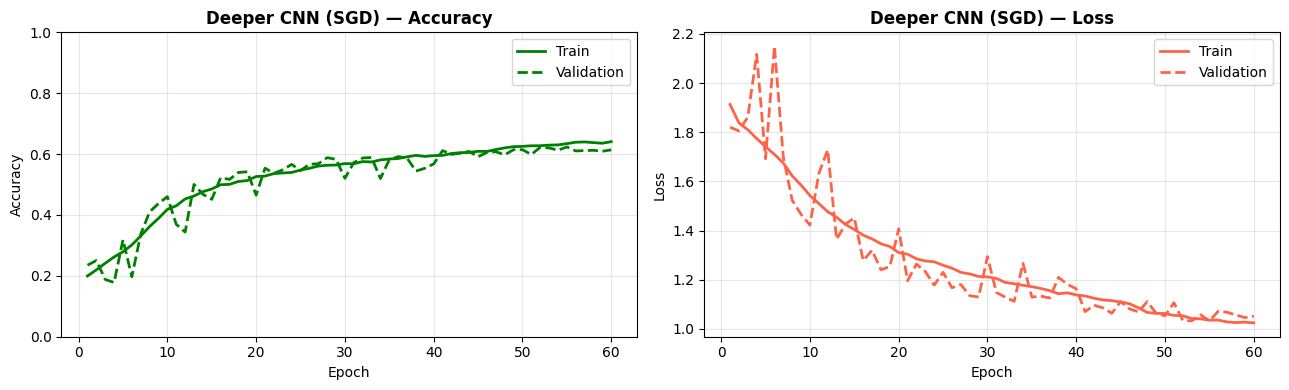

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step

Deeper CNN (SGD) — Test Accuracy: 63.78%
              precision    recall  f1-score   support

       angry      0.598     0.556     0.577       958
        fear      0.551     0.368     0.441      1024
       happy      0.819     0.865     0.841      1774
     neutral      0.499     0.719     0.589      1233
         sad      0.544     0.453     0.494      1247
    surprise      0.760     0.736     0.748       831

    accuracy                          0.638      7067
   macro avg      0.629     0.616     0.615      7067
weighted avg      0.639     0.638     0.631      7067



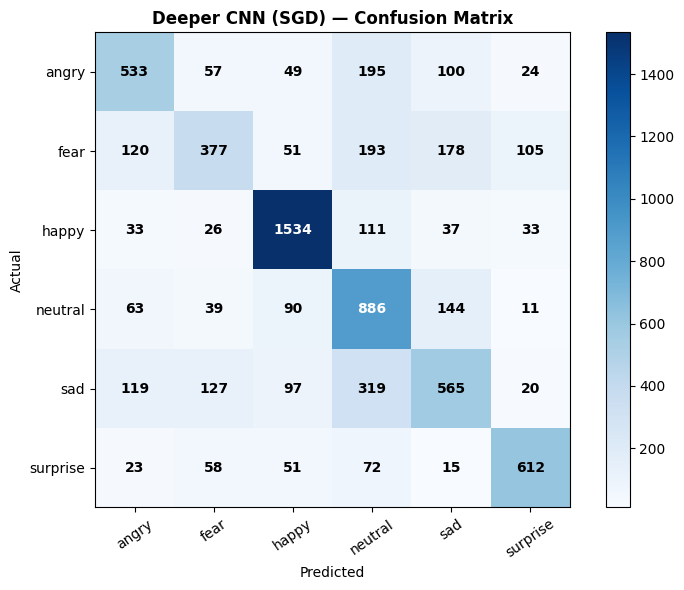

In [28]:
plot_history(sgd_history, 'Deeper CNN (SGD)', color='green')
sgd_preds, sgd_true, sgd_acc = evaluate_model(sgd_model, test_gen, 'Deeper CNN (SGD)')


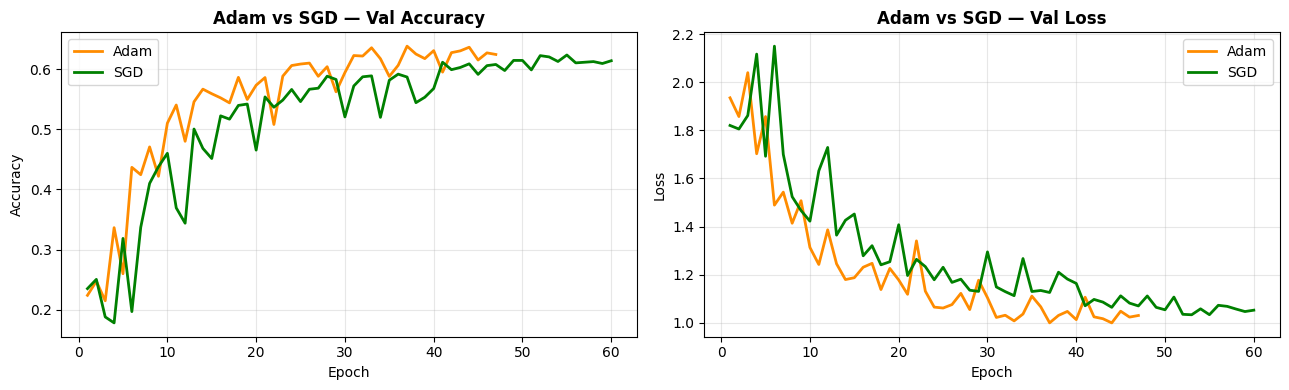

In [29]:
# Adam vs SGD overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_d = range(1, len(deeper_history.history['val_accuracy']) + 1)
e_s = range(1, len(sgd_history.history['val_accuracy'])   + 1)

axes[0].plot(e_d, deeper_history.history['val_accuracy'], label='Adam', lw=2, color='darkorange')
axes[0].plot(e_s, sgd_history.history['val_accuracy'],   label='SGD',  lw=2, color='green')
axes[0].set_title('Adam vs SGD — Val Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e_d, deeper_history.history['val_loss'], label='Adam', lw=2, color='darkorange')
axes[1].plot(e_s, sgd_history.history['val_loss'],   label='SGD',  lw=2, color='green')
axes[1].set_title('Adam vs SGD — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Ablation Study — Remove Dropout

In [30]:
def build_ablation_no_dropout():
    model = Sequential([
        # Block 1
        Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(), MaxPooling2D(2,2),

        # Block 2
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),

        # Block 3+4
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),

        # Block 5+6
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),

        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Ablation_NoDropout')
    return model

ablation_model = build_ablation_no_dropout()
ablation_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("Ablation model (No Dropout) compiled")

t0 = time.time()
ablation_history = ablation_model.fit(
    train_gen,
    epochs          = 40,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=8),
    verbose         = 1
)
ablation_time = (time.time() - t0) / 60
print(f"\nAblation Training Time: {ablation_time:.1f} min")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Ablation model (No Dropout) compiled
Epoch 1/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.2919 - loss: 1.7879 - val_accuracy: 0.2071 - val_loss: 2.3037 - learning_rate: 5.0000e-04
Epoch 2/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.4074 - loss: 1.5689 - val_accuracy: 0.4643 - val_loss: 1.4499 - learning_rate: 5.0000e-04
Epoch 3/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.4639 - loss: 1.4458 - val_accuracy: 0.2947 - val_loss: 1.9248 - learning_rate: 5.0000e-04
Epoch 4/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.5097 - loss: 1.3589 - val_accuracy: 0.4830 - val_loss: 1.3783 - learning_rate: 5.0000e-04
Epoch 5/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.5285 - loss: 1.3001 - val_accuracy: 0.5168 - val_loss: 1.3266 - learning_rate: 5.0000e-04
Epoch 6/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.5514 - loss: 1.2475 - val_accuracy: 0.5235 - val_loss: 1.2816 - learning_rate: 5.0000e-04
Epoch 7/40
354/

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step

Ablation (No Dropout) — Test Accuracy: 65.01%
              precision    recall  f1-score   support

       angry      0.554     0.624     0.587       958
        fear      0.533     0.451     0.489      1024
       happy      0.882     0.807     0.843      1774
     neutral      0.553     0.687     0.613      1233
         sad      0.546     0.488     0.515      1247
    surprise      0.760     0.779     0.769       831

    accuracy                          0.650      7067
   macro avg      0.638     0.639     0.636      7067
weighted avg      0.656     0.650     0.650      7067



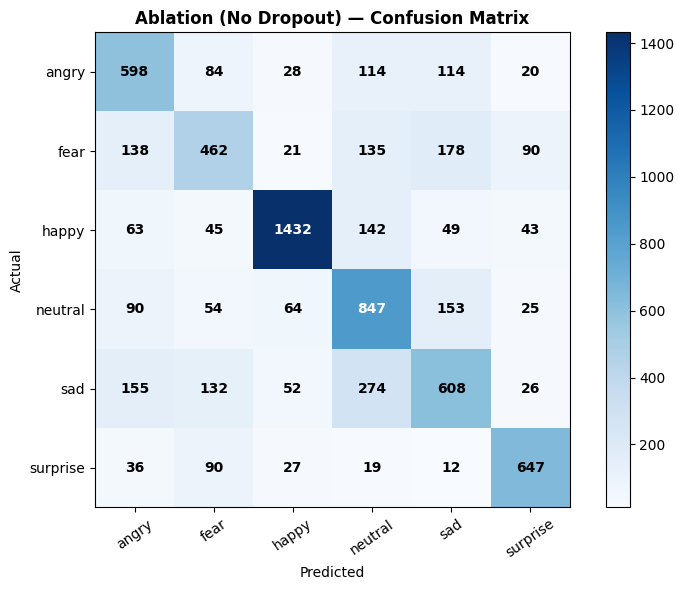

In [31]:
ab_preds, ab_true, ablation_acc = evaluate_model(ablation_model, test_gen, 'Ablation (No Dropout)')


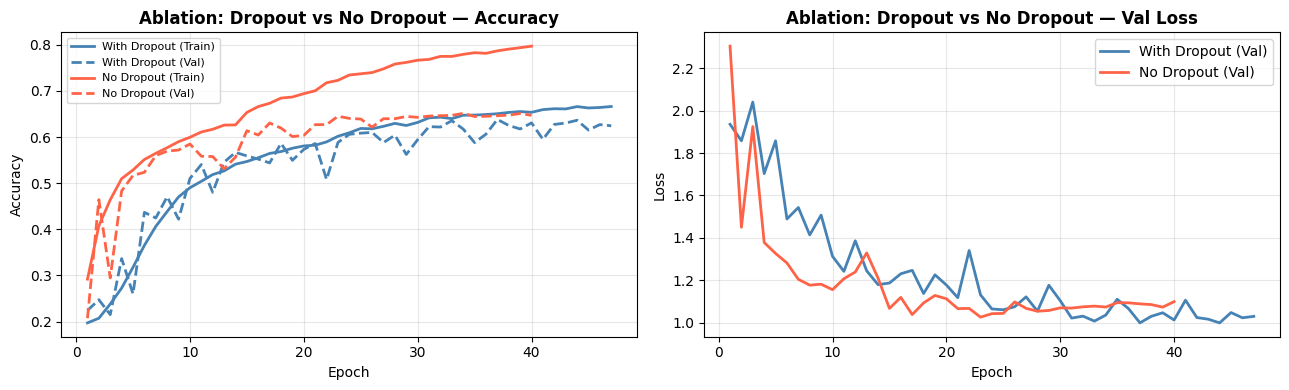


Ablation Finding:
  Train-Val gap WITH Dropout   : 2.8%
  Train-Val gap WITHOUT Dropout: 14.6%


In [32]:
# With vs Without Dropout overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_d  = range(1, len(deeper_history.history['val_accuracy'])   + 1)
e_ab = range(1, len(ablation_history.history['val_accuracy']) + 1)

axes[0].plot(e_d,  deeper_history.history['train_accuracy']   if 'train_accuracy' in deeper_history.history
             else deeper_history.history['accuracy'], label='With Dropout (Train)', lw=2, ls='-',  color='steelblue')
axes[0].plot(e_d,  deeper_history.history['val_accuracy'],   label='With Dropout (Val)',   lw=2, ls='--', color='steelblue')
axes[0].plot(e_ab, ablation_history.history['accuracy'],     label='No Dropout (Train)',  lw=2, ls='-',  color='tomato')
axes[0].plot(e_ab, ablation_history.history['val_accuracy'], label='No Dropout (Val)',    lw=2, ls='--', color='tomato')
axes[0].set_title('Ablation: Dropout vs No Dropout — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(e_d,  deeper_history.history['val_loss'],   label='With Dropout (Val)',  lw=2, color='steelblue')
axes[1].plot(e_ab, ablation_history.history['val_loss'], label='No Dropout (Val)',    lw=2, color='tomato')
axes[1].set_title('Ablation: Dropout vs No Dropout — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAblation Finding:")
gap_with    = max(deeper_history.history['accuracy'])   - max(deeper_history.history['val_accuracy'])
gap_without = max(ablation_history.history['accuracy']) - max(ablation_history.history['val_accuracy'])
print(f"  Train-Val gap WITH Dropout   : {gap_with*100:.1f}%")
print(f"  Train-Val gap WITHOUT Dropout: {gap_without*100:.1f}%")

### Part A Summary Table

In [33]:
summary = pd.DataFrame({
    'Model'         : ['Baseline (Adam)', 'Deeper (Adam)', 'Deeper (SGD)', 'Ablation (No Dropout)'],
    'Params'        : [f"{baseline_model.count_params():,}",
                       f"{deeper_model.count_params():,}",
                       f"{sgd_model.count_params():,}",
                       f"{ablation_model.count_params():,}"],
    'Epochs'        : [len(baseline_history.history['accuracy']),
                       len(deeper_history.history['accuracy']),
                       len(sgd_history.history['accuracy']),
                       len(ablation_history.history['accuracy'])],
    'Train Time'    : [f'{baseline_time:.1f}m', f'{deeper_time:.1f}m',
                       f'{sgd_time:.1f}m',      f'{ablation_time:.1f}m'],
    'Best Val Acc'  : [f"{max(baseline_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(deeper_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(sgd_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(ablation_history.history['val_accuracy'])*100:.1f}%"],
    'Test Accuracy' : [f'{baseline_acc:.1f}%', f'{deeper_acc:.1f}%',
                       f'{sgd_acc:.1f}%',      f'{ablation_acc:.1f}%'],
})
print("\n" + "=" * 75)
print("PART A — COMPLETE MODEL COMPARISON")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)
print("Hardware: Google Colab T4 GPU")


PART A — COMPLETE MODEL COMPARISON
                Model    Params  Epochs Train Time Best Val Acc Test Accuracy
      Baseline (Adam) 1,316,550      60      20.4m        63.3%         63.7%
        Deeper (Adam) 1,762,118      47      17.5m        63.8%         65.2%
         Deeper (SGD) 1,762,118      60      23.8m        62.3%         63.8%
Ablation (No Dropout) 1,762,118      40      13.9m        65.1%         65.0%
Hardware: Google Colab T4 GPU


#PART B — Transfer Learning with MobileNetV2

##Build MobileNetV2 Model

In [34]:
# PART B — Transfer Learning with MobileNetV2

TL_IMG_SIZE = (96, 96)
TL_BATCH    = 64

preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_fn,
    validation_split=0.2,
    rotation_range=8,
    zoom_range=0.08,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=True
)
tl_val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_fn, validation_split=0.2)
tl_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', subset='training', seed=SEED
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    train_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', subset='validation', seed=SEED
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    test_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', shuffle=False
)

print(f"Transfer Learning generators ready at {TL_IMG_SIZE} RGB")
print(f"Train: {tl_train_gen.samples} | Val: {tl_val_gen.samples} | Test: {tl_test_gen.samples}")

# Sanity check — must be (BATCH, 96, 96, 3)
batch_x, batch_y = next(tl_train_gen)
print(f"Input batch shape : {batch_x.shape}")
print(f"Pixel range       : [{batch_x.min():.2f}, {batch_x.max():.2f}]")  # Should be ~[-1, 1]

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Transfer Learning generators ready at (96, 96) RGB
Train: 22619 | Val: 5654 | Test: 7067
Input batch shape : (64, 96, 96, 3)
Pixel range       : [-1.00, 1.00]


In [35]:
# Build MobileNetV2 Model

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Phase 1: Freeze entire base
base_model.trainable = False

# Custom classification head
inputs = Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_FER')

tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(w.numpy().size for w in tl_model.trainable_weights)
total     = tl_model.count_params()
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  (head only)")
print(f"Frozen params   : {total - trainable:,}  (MobileNetV2 base)")
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params    : 2,621,126
Trainable params: 362,374  (head only)
Frozen params   : 2,258,752  (MobileNetV2 base)


Model: "MobileNetV2_FER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,126 (10.00 MB)

 Trainable params: 362,374 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

##Phase 1 — Feature Extraction (Frozen Base)


TL Class Weights:
  angry       : 1.180
  fear        : 1.150
  happy       : 0.653
  neutral     : 0.949
  sad         : 0.976
  surprise    : 1.486

Phase 1: Feature Extraction (base frozen)...
Epoch 1/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 115s 272ms/step - accuracy: 0.3471 - loss: 1.8452 - val_accuracy: 0.3741 - val_loss: 1.6659 - learning_rate: 0.0010
Epoch 2/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.4149 - loss: 1.5654 - val_accuracy: 0.4188 - val_loss: 1.5252 - learning_rate: 0.0010
Epoch 3/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 69s 195ms/step - accuracy: 0.4413 - loss: 1.4974 - val_accuracy: 0.4167 - val_loss: 1.5455 - learning_rate: 0.0010
Epoch 4/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 69s 195ms/step - accuracy: 0.4524 - loss: 1.4646 - val_accuracy: 0.4264 - val_loss: 1.5091 - learning_rate: 0.0010
Epoch 5/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.4629 - loss: 1.4437 - val_accuracy: 0.4316 - val_loss: 1.5007 - learning_rate: 0.0010
Epoch 6/20
354/354 ━━━━━━━━━

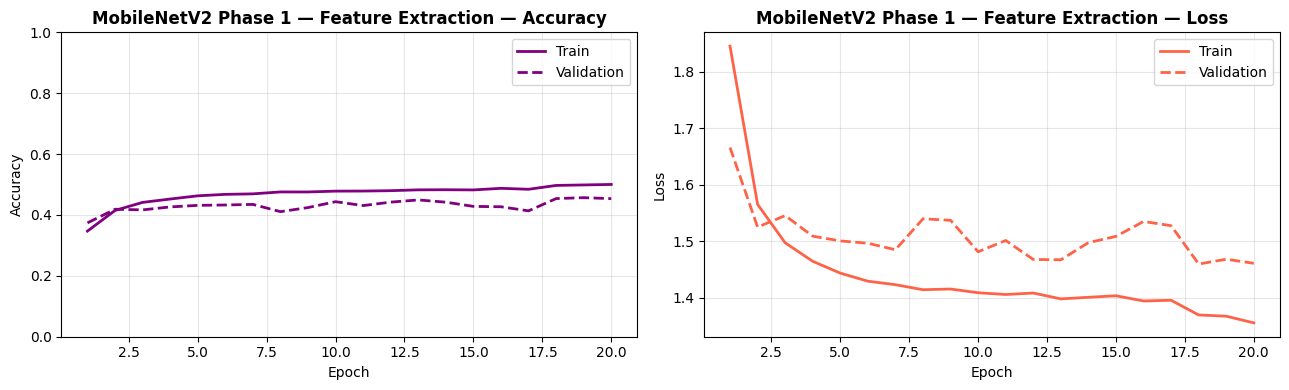

In [36]:
# Phase 1 — Feature Extraction (Frozen Base)

tl_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=tl_train_gen.classes
)
tl_cw = dict(enumerate(tl_class_weights))
print("TL Class Weights:")
for i, cls in enumerate(classes):
    print(f"  {cls:<12}: {tl_cw[i]:.3f}")

print("\nPhase 1: Feature Extraction (base frozen)...")
t0 = time.time()

history_p1 = tl_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    class_weight=tl_cw,
    callbacks=get_callbacks(patience_lr=4, patience_es=8),
    verbose=1
)

p1_time = (time.time() - t0) / 60
print(f"\nPhase 1 Time: {p1_time:.1f} min")
print(f"Epochs completed: {len(history_p1.history['accuracy'])}")

plot_history(history_p1, 'MobileNetV2 Phase 1 — Feature Extraction', color='purple')

##Phase 2 — Fine-Tuning (Unfreeze Top 30 Layers)

Total base layers      : 154
Fine-tuning from layer : 104
Trainable layers       : 50
Trainable params after unfreeze: 2,217,478
Epoch 1/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 115s 255ms/step - accuracy: 0.3822 - loss: 1.6513 - val_accuracy: 0.4531 - val_loss: 1.5405 - learning_rate: 1.0000e-05
Epoch 2/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 71s 200ms/step - accuracy: 0.4396 - loss: 1.4980 - val_accuracy: 0.4630 - val_loss: 1.4695 - learning_rate: 1.0000e-05
Epoch 3/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 71s 200ms/step - accuracy: 0.4643 - loss: 1.4382 - val_accuracy: 0.4682 - val_loss: 1.4237 - learning_rate: 1.0000e-05
Epoch 4/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 71s 199ms/step - accuracy: 0.4826 - loss: 1.3995 - val_accuracy: 0.4744 - val_loss: 1.3980 - learning_rate: 1.0000e-05
Epoch 5/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 69s 195ms/step - accuracy: 0.4983 - loss: 1.3639 - val_accuracy: 0.4837 - val_loss: 1.3762 - learning_rate: 1.0000e-05
Epoch 6/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.5093 -

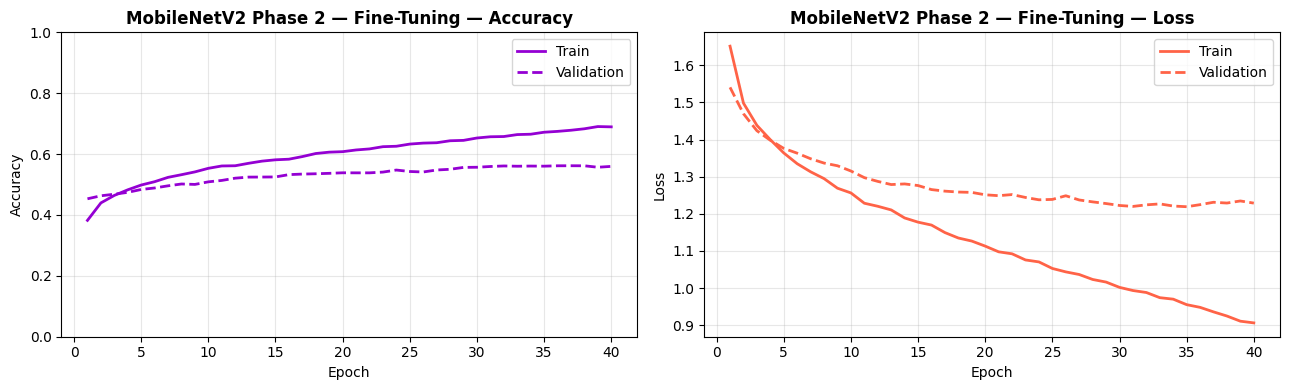

In [37]:
# Phase 2 — Fine-Tuning (Unfreeze Top 50 Layers)

base_model.trainable = True

# Freeze all but last 50 layers
fine_tune_from = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Total base layers      : {len(base_model.layers)}")
print(f"Fine-tuning from layer : {fine_tune_from}")
print(f"Trainable layers       : {len(base_model.layers) - fine_tune_from}")

tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ft_trainable = sum(w.numpy().size for w in tl_model.trainable_weights)
print(f"Trainable params after unfreeze: {ft_trainable:,}")

t0 = time.time()
history_p2 = tl_model.fit(
    tl_train_gen,
    epochs=40,
    validation_data=tl_val_gen,
    class_weight=tl_cw,
    callbacks=get_callbacks(patience_lr=4, patience_es=10),
    verbose=1
)
p2_time = (time.time() - t0) / 60
print(f"\nPhase 2 Fine-Tuning Time: {p2_time:.1f} min")
print(f"Epochs completed: {len(history_p2.history['accuracy'])}")

plot_history(history_p2, 'MobileNetV2 Phase 2 — Fine-Tuning', color='darkviolet')

##Transfer Learning Evaluation

111/111 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step

MobileNetV2 Transfer Learning — Test Accuracy: 56.59%
              precision    recall  f1-score   support

       angry      0.559     0.364     0.441       958
        fear      0.487     0.302     0.373      1024
       happy      0.796     0.744     0.769      1774
     neutral      0.461     0.607     0.524      1233
         sad      0.409     0.570     0.476      1247
    surprise      0.713     0.677     0.695       831

    accuracy                          0.566      7067
   macro avg      0.571     0.544     0.546      7067
weighted avg      0.583     0.566     0.564      7067



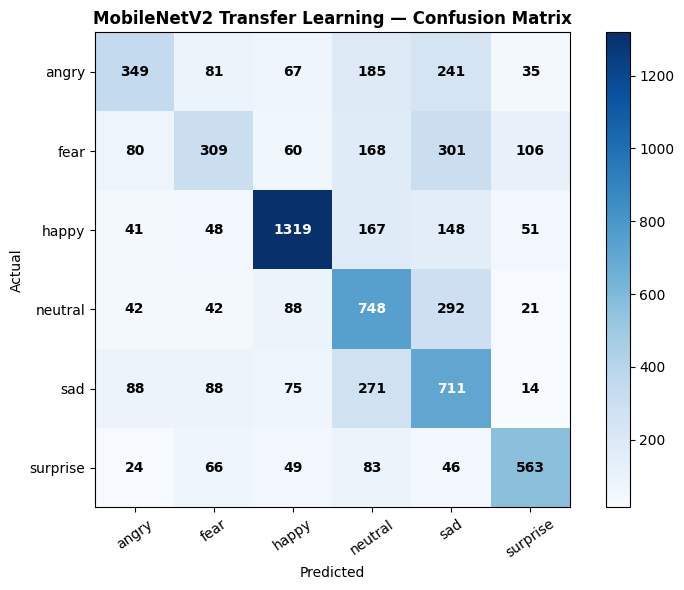

In [38]:
tl_preds, tl_true, tl_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 Transfer Learning')


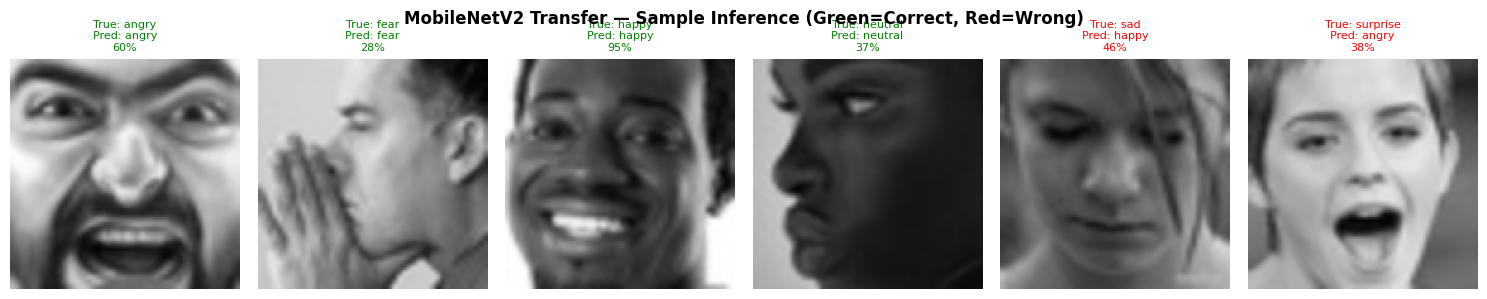

In [39]:
sample_inference(tl_model, test_dir, classes, 'MobileNetV2 Transfer', 'rgb', (96, 96))

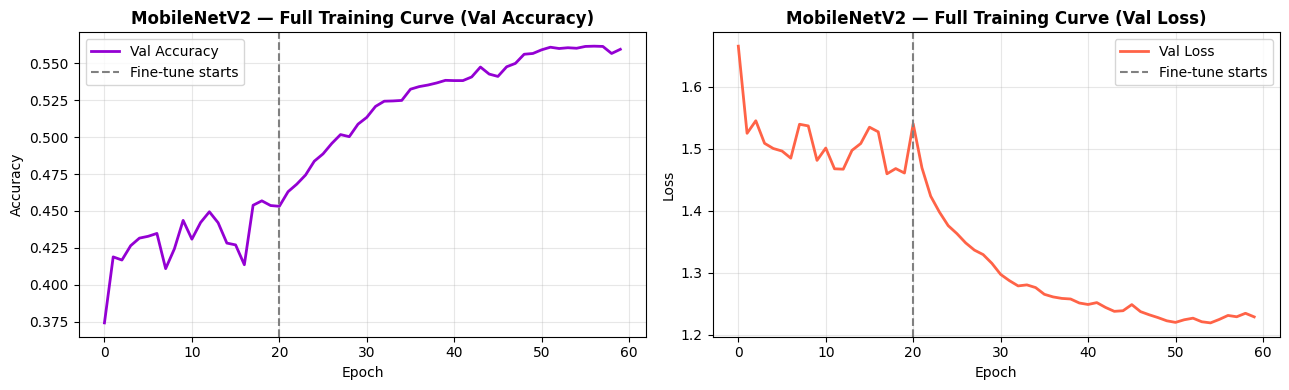

In [40]:
# Phase 1 vs Phase 2 full curve
combined_val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
combined_val_loss = history_p1.history['val_loss']    + history_p2.history['val_loss']
phase1_end = len(history_p1.history['val_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(combined_val_acc, lw=2, color='darkviolet', label='Val Accuracy')
axes[0].axvline(x=phase1_end, color='gray', ls='--', lw=1.5, label='Fine-tune starts')
axes[0].set_title('MobileNetV2 — Full Training Curve (Val Accuracy)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(combined_val_loss, lw=2, color='tomato', label='Val Loss')
axes[1].axvline(x=phase1_end, color='gray', ls='--', lw=1.5, label='Fine-tune starts')
axes[1].set_title('MobileNetV2 — Full Training Curve (Val Loss)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# FINAL COMPLETE COMPARISON — All 5 Models


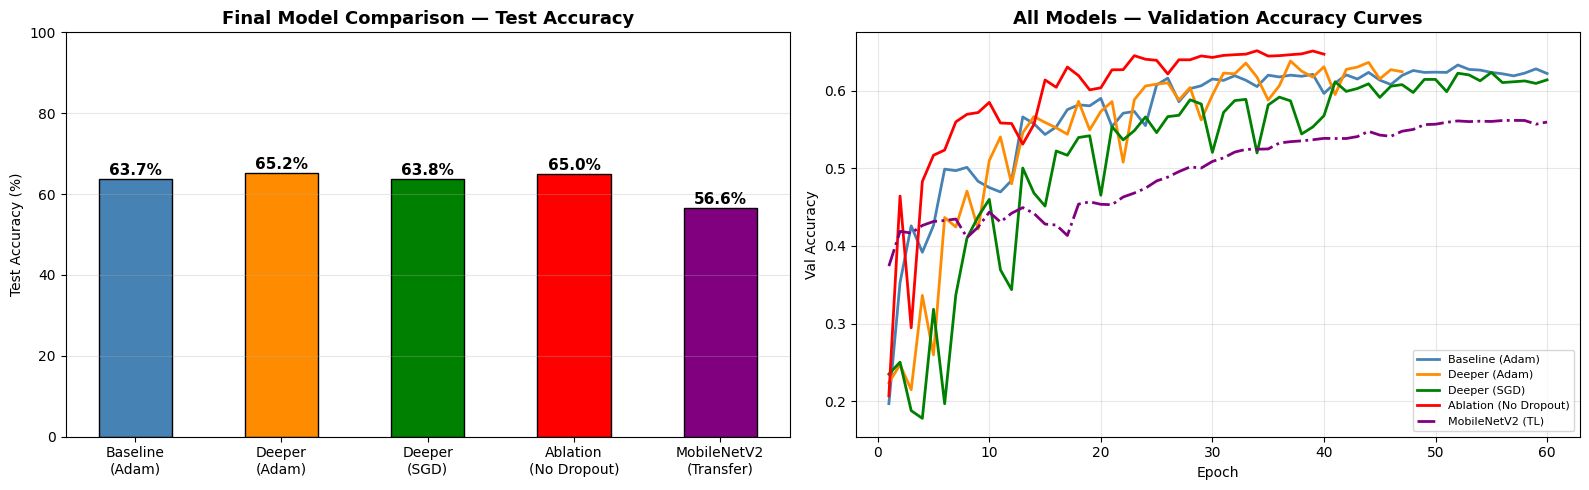


COMPLETE FINAL MODEL COMPARISON
                 Model    Params  Epochs Train Time Test Accuracy
       Baseline (Adam) 1,316,550      60      20.4m         63.7%
         Deeper (Adam) 1,762,118      47      17.5m         65.2%
          Deeper (SGD) 1,762,118      60      23.8m         63.8%
 Ablation (No Dropout) 1,762,118      40      13.9m         65.0%
MobileNetV2 (Transfer) 2,621,126      60      71.7m         56.6%
All training performed on Google Colab with T4 GPU acceleration.


In [43]:
model_names = ['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)',
               'Ablation\n(No Dropout)', 'MobileNetV2\n(Transfer)']
accuracies  = [baseline_acc, deeper_acc, sgd_acc, ablation_acc, tl_acc]
colors      = ['steelblue', 'darkorange', 'green', 'red', 'purple']

# Define model_histories for plotting all models on one plot
model_histories = [
    (baseline_history, 'Baseline (Adam)', 'steelblue'),
    (deeper_history, 'Deeper (Adam)', 'darkorange'),
    (sgd_history, 'Deeper (SGD)', 'green'),
    (ablation_history, 'Ablation (No Dropout)', 'red'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(model_names, accuracies, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Final Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Val accuracy all models on one plot
for hist, label, color in model_histories:
    e = range(1, len(hist.history['val_accuracy']) + 1)
    axes[1].plot(e, hist.history['val_accuracy'], label=label, lw=2, color=color)
tl_e = range(1, len(combined_val_acc) + 1)
axes[1].plot(tl_e, combined_val_acc, label='MobileNetV2 (TL)', lw=2, color='purple', ls='-.')
axes[1].set_title('All Models — Validation Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final table
tl_total_time = p1_time + p2_time
final_summary = pd.DataFrame({
    'Model'         : ['Baseline (Adam)', 'Deeper (Adam)', 'Deeper (SGD)',
                       'Ablation (No Dropout)', 'MobileNetV2 (Transfer)'],
    'Params'        : [f"{baseline_model.count_params():,}",
                       f"{deeper_model.count_params():,}",
                       f"{sgd_model.count_params():,}",
                       f"{ablation_model.count_params():,}",
                       f"{tl_model.count_params():,}"],
    'Epochs'        : [len(baseline_history.history['accuracy']),
                       len(deeper_history.history['accuracy']),
                       len(sgd_history.history['accuracy']),
                       len(ablation_history.history['accuracy']),
                       len(history_p1.history['accuracy']) + len(history_p2.history['accuracy'])],
    'Train Time'    : [f'{baseline_time:.1f}m', f'{deeper_time:.1f}m',
                       f'{sgd_time:.1f}m', f'{ablation_time:.1f}m',
                       f'{tl_total_time:.1f}m'],
    'Test Accuracy' : [f'{baseline_acc:.1f}%', f'{deeper_acc:.1f}%',
                       f'{sgd_acc:.1f}%', f'{ablation_acc:.1f}%',
                       f'{tl_acc:.1f}%'],
})
print("\n" + "=" * 78)
print("COMPLETE FINAL MODEL COMPARISON")
print("=" * 78)
print(final_summary.to_string(index=False))
print("=" * 78)
print("All training performed on Google Colab with T4 GPU acceleration.")